# Hidden-State Geometry: Goal Drift Detection in Multi-Turn LLM Conversations

Analyses **Llama-3.1-8B-Instruct** hidden states from sharded-GSM8K to detect and quantify  
**goal drift** — the tendency of incorrect reasoning paths to prematurely lock into an answer  
strategy before reasoning has converged.

## Conversation structure

```
[sys + Shard₀] → Answer₀ → [sys + Shard₀ + Ans₀ + Shard₁] → Answer₁ → … → score ∈ {0,1}
```

`hs["turn_t"]` = prefill hidden state **before** generating `Answerₜ`  
→ causally leads to that response; paired with `turn_rt_map[conv_id][t]`.

## Seven response types (fixed across tasks and models)

| Label | Description |
|-------|-------------|
| `answer_attempt` | Direct solution attempt |
| `discussion` | Exploratory reasoning without committing |
| `clarification` | Asking for more information |
| `hedging` | Tentative / qualified answer |
| `interrogation` | Probing the problem |
| `refusal` | Declining to answer |
| `missing` | No verifiable response type |

## Notebook structure

| Section | Content |
|---------|---------|
| **§1** | Setup: imports, config, utilities |
| **§2** | Data loading: `.pt` hidden states + JSONL metadata |
| **§3** | Geometry validation: RT mean vectors + PCA |
| **§4** | Metric A — Temporal Curvature |
| **§5** | Metric B — Strategy Axis Projection |
| **§6** | Metric C — Goal Imprint Gap |
| **§7** | Metric D — Trajectory Variance |
| **§8** | Metric E — Strategy Reversals |
| **§9** | Summary: AUROC comparison |


## §1  Setup

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch

from collections import Counter, defaultdict
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, silhouette_score
from scipy.stats import mannwhitneyu, linregress, zscore
from matplotlib.patches import Patch

In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# Pool two experimental conditions; extend PT_SOURCES / JSONL_SOURCES to add more.
PT_SOURCES = [
    # Path("logs/hidden_states/math/(l20-l31)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct"),
    Path("logs/hidden_states/math/(add_v2)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct"),
]
JSONL_SOURCES = [
    # Path("logs/math/sharded-at0-ut0/(l20-l31)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl"),
    Path("logs/math/sharded-at0-ut0/(add_v2)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl"),
]

# ── Model / layer config ───────────────────────────────────────────────────────
# Change LAYERS to match the target model's depth.
# Llama-3.1-8B has 32 layers; Qwen2.5-32B has 64 layers, etc.
LAYERS          = [12, 16, 20, 24, 28]   # which layers to load
FOCUS_LAYER_IDX = LAYERS.index(24)       # primary analysis layer (index into LAYERS)

# ── Response-type taxonomy (fixed; shared across tasks and models) ─────────────
# These seven types are exhaustive for goal-drift analysis.
ALL_TYPES = [
    "answer_attempt",   # direct solution attempt
    "discussion",       # exploratory reasoning
    "clarification",    # asks for more info
    "hedging",          # tentative / qualified
    "interrogation",    # probes the problem
    "refusal",          # declines
    "missing",          # verifier returned no type
]

# Normalise raw verifier labels to canonical names
RT_NORM = {"hedge": "hedging", "refuse": "refusal"}

# Strategy axis poles: the two types that define the commit vs explore axis.
# Override here if your task has a different primary commitment pair.
STRATEGY_POS = "answer_attempt"   # pole indicating commitment
STRATEGY_NEG = "discussion"       # pole indicating exploration

TYPE_COLORS = {
    "answer_attempt": "#2196F3",
    "clarification" : "#4CAF50",
    "refusal"       : "#F44336",
    "hedging"       : "#FF9800",
    "interrogation" : "#9C27B0",
    "discussion"    : "#00BCD4",
    "missing"       : "#9E9E9E",
}

In [3]:
# ── Utility functions ─────────────────────────────────────────────────────────

def turn_sort_key(label: str):
    """Sort 'turn_N' labels numerically (turn_1 < turn_2 < … < turn_10)."""
    if not label.startswith("turn_"):
        return (1, label)
    try:
        return (0, int(label.split("_", 1)[1]))
    except ValueError:
        return (0, label)

def turn_index(label: str) -> int:
    return int(label.split("_", 1)[1])

def cosine(a, b) -> float:
    """Cosine similarity; NaN if either vector is near-zero."""
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(np.dot(a, b) / (na * nb)) if (na > 1e-9 and nb > 1e-9) else np.nan

def styled_ax(ax):
    """Light-theme axis styling."""
    pass

# ── Statistical helpers ───────────────────────────────────────────────────────

def mw_test(vc, vi, alternative="two-sided"):
    """Mann-Whitney U; returns (star_str, p_value). Requires n≥5 per group."""
    if len(vc) < 5 or len(vi) < 5:
        return "—", float("nan")
    _, p = mannwhitneyu(vc, vi, alternative=alternative)
    star = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    return star, p

def best_auroc(labels, values):
    """AUROC maximised over both signal directions. Returns (auc, direction_char)."""
    auc_pos = roc_auc_score(labels, values)
    auc_neg = roc_auc_score(labels, [-v for v in values])
    if auc_pos >= auc_neg:
        return auc_pos, "+"
    return auc_neg, "-"

def print_metric_table(records, metrics, score_key="score"):
    """Print a per-metric stats table (mean, n, MW p, AUROC) for quick inspection."""
    header = f"{'metric':>14}  {'corr_μ':>8}  n_c  {'incorr_μ':>9}  n_i  {'p(MW)':>9}  sig   AUROC"
    print(header)
    print("─" * len(header))
    auroc_dict = {}
    for metric in metrics:
        vc = [r[metric] for r in records if r[score_key]==1 and not np.isnan(r.get(metric, float("nan")))]
        vi = [r[metric] for r in records if r[score_key]==0 and not np.isnan(r.get(metric, float("nan")))]
        if not vc or not vi:
            continue
        star, p = mw_test(vc, vi)
        labs = [r[score_key] for r in records if not np.isnan(r.get(metric, float("nan")))]
        vals = [r[metric]    for r in records if not np.isnan(r.get(metric, float("nan")))]
        auc, direc = best_auroc(labs, vals)
        auroc_dict[metric] = (auc, direc)
        print(f"{metric:>14}  {np.mean(vc):>+8.4f}  {len(vc):>3}  {np.mean(vi):>+9.4f}"
              f"  {len(vi):>3}  {p:>9.4g}  {star:<5} {auc:.4f} ({direc})")
    return auroc_dict

# Global registry: metrics register their AUROC here for §9 summary
METRIC_AUROCS = {}   # metric_name → (auroc, direction, color)

## §2  Data Loading

Two sources loaded and merged into flat dicts keyed by `conv_id`:

- **`conv_records`** — per-conversation hidden states at each turn for each layer  
- **`score_map`** — binary correctness label (0/1)  
- **`turn_rt_map`** — per-turn response type from the verifier log


In [4]:
# ── 2.1 Load .pt hidden-state files ──────────────────────────────────────────
# Each file: conv_id.pt → {"hidden_states": [{"label": str, "hidden_states": [tensor×layer]}]}
# Labels: "goal" (prefill of shard₀ only) + "turn_1", "turn_2", …
# Minimum 3 turns required (curvature needs 2 consecutive deltas).

conv_records = {}
seen, skip_stats = set(), defaultdict(int)

for pt_dir in PT_SOURCES:
    pt_files = sorted(pt_dir.glob("*.pt"))
    print(f"  {pt_dir.name[:60]}: {len(pt_files)} files")

    for pt_file in pt_files:
        conv_id = pt_file.stem
        if conv_id in seen:
            skip_stats["duplicate"] += 1; continue
        seen.add(conv_id)

        data        = torch.load(pt_file, map_location="cpu", weights_only=False)
        hs_by_label = {e["label"]: e["hidden_states"] for e in data.get("hidden_states", [])}

        if "goal" not in hs_by_label:
            skip_stats["no_goal"] += 1; continue

        turn_labels = sorted(
            [k for k in hs_by_label if k.startswith("turn_")], key=turn_sort_key
        )
        if len(turn_labels) < 3:
            skip_stats["too_few_turns"] += 1; continue

        conv_records[conv_id] = {
            # goal_hs[layer_idx] → numpy array (hidden_dim,)
            "goal_hs" : [hs_by_label["goal"][i].numpy() for i in range(len(LAYERS))],
            # turns_hs[turn_label][layer_idx] → numpy array (hidden_dim,)
            "turns_hs": {tl: [hs_by_label[tl][i].numpy() for i in range(len(LAYERS))]
                         for tl in turn_labels},
            "max_turn": max(turn_index(tl) for tl in turn_labels),
        }

print(f"\nLoaded: {len(conv_records)} conversations")
for k, v in skip_stats.items():
    if v: print(f"  Skipped ({k}): {v}")

  (add_v2)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruc: 241 files

Loaded: 219 conversations
  Skipped (too_few_turns): 22


In [5]:
# ── 2.2 Load JSONL → score_map + turn_rt_map ─────────────────────────────────
# score_map[conv_id]        → int (0 or 1)
# turn_rt_map[conv_id][t]   → response type of Answer_t (paired with hs["turn_t"])
#
# Alignment: user_turn_idx increments on each "user" entry;
# the "system-verification" log entry immediately follows the assistant turn,
# so turn_rt_map[conv_id][N] is the type of Answer_N, correctly paired with
# hs["turn_N"] (the pre-Answer_N hidden state).

score_map   = {}
turn_rt_map = {}

for jsonl_path in JSONL_SOURCES:
    loaded = 0
    with open(jsonl_path) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            rec     = json.loads(line)
            conv_id = rec.get("conv_id")
            if conv_id is None: continue

            score = rec.get("score")
            score_map[conv_id] = int(float(score)) if score is not None else 0

            trace, turn_rt, user_turn_idx = rec.get("trace", []), {}, 0
            for entry in trace:
                role = entry.get("role", "")
                if role == "user":
                    user_turn_idx += 1
                elif role == "log":
                    content = entry.get("content", {})
                    if isinstance(content, dict) and content.get("type") == "system-verification":
                        rt = content.get("response", {}).get("response_type", "missing")
                        rt = RT_NORM.get(rt, rt)
                        turn_rt[user_turn_idx] = rt
            turn_rt_map[conv_id] = turn_rt
            loaded += 1

    print(f"  {jsonl_path.name[:60]}: {loaded} records")

n_c = sum(v == 1 for v in score_map.values())
n_i = sum(v == 0 for v in score_map.values())
print(f"\nTotal: {len(score_map)}  (correct={n_c}, incorrect={n_i})")
print("RT distribution:", Counter(rt for d in turn_rt_map.values() for rt in d.values()))

  (add_v2)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruc: 241 records

Total: 241  (correct=128, incorrect=113)
RT distribution: Counter({'answer_attempt': 509, 'discussion': 378, 'clarification': 194, 'interrogation': 20, 'hedging': 15, 'refusal': 13, 'missing': 8})


## §3  Response-Type Geometry Validation

Before computing derived metrics, we validate that the seven response types  
occupy meaningfully different regions of hidden-state space.

**3.1** — Build a mean vector per RT per layer (used by all downstream analyses).  
**3.2** — PCA on all individual samples to assess raw separability.

**Metrics:**
- **Silhouette score** (PC1+PC2): −1 = opposite sides, 0 = overlap, +1 = clean separation  
- **Between/within-class variance ratio** per PC: ≫1 = separable, ≈1 = overlapping


In [6]:
# ── 3.1 RT mean vectors ───────────────────────────────────────────────────────
# rt_accum[layer_idx][rt] → list of hidden-state arrays for that (layer, RT) pair
# rt_vectors[layer_idx][rt] → mean vector (hidden_dim,)
# These are the "role vectors" used to build the strategy axis in §5.

rt_accum = {li: defaultdict(list) for li in range(len(LAYERS))}

for conv_id, rec in conv_records.items():
    turn_rt = turn_rt_map.get(conv_id, {})
    for t_label, hs_per_layer in rec["turns_hs"].items():
        t_idx = turn_index(t_label)
        rt    = turn_rt.get(t_idx, "missing")
        for li, hs in enumerate(hs_per_layer):
            rt_accum[li][rt].append(hs)

rt_vectors = {
    li: {rt: np.mean(vecs, axis=0) for rt, vecs in rt_accum[li].items()}
    for li in range(len(LAYERS))
}

print(f"Sample counts per RT — layer {LAYERS[FOCUS_LAYER_IDX]}:")
for rt in ALL_TYPES:
    n = len(rt_accum[FOCUS_LAYER_IDX].get(rt, []))
    bar = "█" * min(n // 5, 40)
    print(f"  {rt:<18} n={n:>5}  {bar}")

Sample counts per RT — layer 24:
  answer_attempt     n=  287  ████████████████████████████████████████
  discussion         n=  355  ████████████████████████████████████████
  clarification      n=  187  █████████████████████████████████████
  hedging            n=   15  ███
  interrogation      n=   20  ████
  refusal            n=   12  ██
  missing            n=    8  █


Total samples: 884

Variance explained (layer 24):
  PC1: 13.79%
  PC2: 9.63%
  PC3: 6.62%
  PC4: 4.85%
  PC5: 4.41%

Silhouette score (PC1+PC2, n=884): -0.1402
  −1 = opposite sides · 0 = heavy overlap · +1 = clean separation


/tmp/ipykernel_602413/3214919684.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


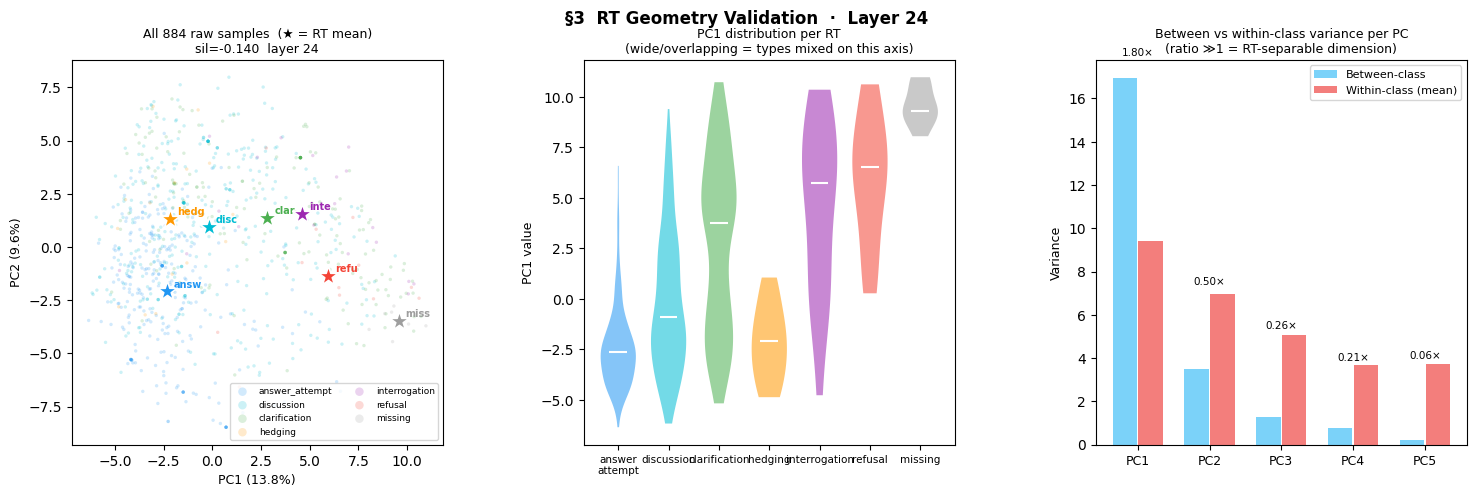

In [7]:
# ── 3.2 PCA on all individual hidden states ───────────────────────────────────
# Fit PCA on the pooled raw samples (no averaging).
# Produces the global_mean used to centre all subsequent projections.

TARGET_LI = FOCUS_LAYER_IDX
rng       = np.random.default_rng(42)

# Stack all samples
present_rts = [rt for rt in ALL_TYPES
               if rt in rt_accum[TARGET_LI] and len(rt_accum[TARGET_LI][rt]) > 0]

big_X_list, big_y_list = [], []
for rt in present_rts:
    big_X_list.extend(rt_accum[TARGET_LI][rt])
    big_y_list.extend([rt] * len(rt_accum[TARGET_LI][rt]))

big_X = np.stack(big_X_list)   # (N_total, hidden_dim)
big_y = np.array(big_y_list)

# Fit PCA and store global mean — used to centre projections in §5/§6
global_mean = big_X.mean(axis=0)
pca         = PCA(n_components=5)
Z           = pca.fit_transform(big_X - global_mean)

print(f"Total samples: {len(big_X)}")
print(f"\nVariance explained (layer {LAYERS[TARGET_LI]}):")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v*100:.2f}%")

# Silhouette on PC1+PC2 subset
N_SIL = 2000
idx_sil = rng.choice(len(big_X), min(N_SIL, len(big_X)), replace=False)
sil = silhouette_score(Z[idx_sil, :2], big_y[idx_sil])
print(f"\nSilhouette score (PC1+PC2, n={len(idx_sil)}): {sil:.4f}")
print("  −1 = opposite sides · 0 = heavy overlap · +1 = clean separation")

# Project RT means into the same PCA space
rt_means_proj = {
    rt: pca.transform((rt_vectors[TARGET_LI][rt] - global_mean).reshape(1, -1))[0]
    for rt in present_rts
}

# ── Figure: 3 panels ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 5))

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# Panel A — scatter PC1 vs PC2, all individual samples + RT means (★)
ax = fig.add_subplot(gs[0]); styled_ax(ax)
for rt in present_rts:
    mask = big_y == rt
    ax.scatter(Z[mask, 0], Z[mask, 1], s=6, alpha=0.20,
               color=TYPE_COLORS.get(rt, "#aaa"), edgecolors="none", label=rt)
for rt in present_rts:
    p = rt_means_proj[rt]
    ax.scatter(p[0], p[1], s=220, color=TYPE_COLORS.get(rt, "#aaa"),
               edgecolors="white", linewidths=1.2, zorder=6, marker="*")
    ax.annotate(rt[:4], (p[0], p[1]), xytext=(5, 3),
                textcoords="offset points", fontsize=7,
                color=TYPE_COLORS.get(rt, "#aaa"), fontweight="bold")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=9)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=9)
ax.set_title(f"All {len(big_X)} raw samples  (★ = RT mean)\nsil={sil:.3f}  layer {LAYERS[TARGET_LI]}",
             fontsize=9, pad=5)
ax.legend(fontsize=6.5, ncol=2, markerscale=2.5)

# Panel B — PC1 violin per RT
ax = fig.add_subplot(gs[1]); styled_ax(ax)
pc1_per_rt = [Z[big_y == rt, 0] for rt in present_rts]
vp = ax.violinplot(pc1_per_rt, positions=range(len(present_rts)),
                   widths=0.7, showmedians=True, showextrema=False)
for body, rt in zip(vp["bodies"], present_rts):
    body.set_facecolor(TYPE_COLORS.get(rt, "#aaa")); body.set_alpha(0.55)
vp["cmedians"].set_color("white"); vp["cmedians"].set_linewidth(1.5)
ax.set_xticks(range(len(present_rts)))
ax.set_xticklabels([rt.replace("_", "\n") for rt in present_rts], fontsize=7.5)
ax.set_ylabel("PC1 value", fontsize=9)
ax.set_title("PC1 distribution per RT\n(wide/overlapping = types mixed on this axis)",
             fontsize=9, pad=5)

# Panel C — between-class vs within-class variance ratio per PC
ax = fig.add_subplot(gs[2]); styled_ax(ax)
bc_vars, wc_vars = [], []
for pc_i in range(min(5, pca.n_components_)):
    class_means = [Z[big_y == rt, pc_i].mean() for rt in present_rts if (big_y==rt).sum()>0]
    bc_vars.append(np.var(class_means))
    wc_vars.append(np.mean([Z[big_y==rt, pc_i].var() for rt in present_rts if (big_y==rt).sum()>0]))
x_pc = np.arange(len(bc_vars))
ax.bar(x_pc - 0.18, bc_vars, 0.34, color="#4fc3f7", alpha=0.75, label="Between-class")
ax.bar(x_pc + 0.18, wc_vars, 0.34, color="#ef5350", alpha=0.75, label="Within-class (mean)")
for i in range(len(bc_vars)):
    ratio = bc_vars[i] / wc_vars[i] if wc_vars[i] > 1e-12 else 0
    ax.text(i, max(bc_vars[i], wc_vars[i]) * 1.06, f"{ratio:.2f}×", ha="center",
            fontsize=7.5)
ax.set_xticks(x_pc)
ax.set_xticklabels([f"PC{i+1}" for i in range(len(bc_vars))], fontsize=9)
ax.set_ylabel("Variance", fontsize=9)
ax.set_title("Between vs within-class variance per PC\n(ratio ≫1 = RT-separable dimension)",
             fontsize=9, pad=5)
ax.legend(fontsize=8)

fig.suptitle(f"§3  RT Geometry Validation  ·  Layer {LAYERS[TARGET_LI]}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## §4  Metric A — Temporal Curvature

```
Δhₜ = hₜ − hₜ₋₁                      (displacement in hidden space)
κₜ  = cos(Δhₜ, Δhₜ₋₁) ∈ [−1, +1]    (alignment of consecutive steps)
```

| Range | Interpretation |
|-------|----------------|
| κ > 0 | Trajectory persists (same direction) |
| κ ≈ 0 | Perpendicular turn (exploration) |
| κ < 0 | Reversal (abrupt change) |

**Hypothesis:** Correct paths have smoother, more persistent trajectories.  
**Analysis:** Per-RT curvature distribution + strategy-stay vs strategy-switch.


In [8]:
# ── 4.1 Compute curvature per (conversation, turn) ───────────────────────────
# Curvature at turn t requires two consecutive displacement vectors:
#   delta_{t-1} = hs[t-1] − hs[t-2]
#   delta_t     = hs[t]   − hs[t-1]
#   curvature_t = cos(delta_t, delta_{t-1})
# → defined from the 3rd turn onward (index 2+).
#
# rt alignment: turn_rt[N] = type of Answer_N, paired with hs["turn_N"]
# (pre-Answer_N state) → causally correct.

curv_records = []

for conv_id, rec in conv_records.items():
    score   = score_map.get(conv_id)
    if score is None: continue
    turn_rt = turn_rt_map.get(conv_id, {})

    turn_labels = sorted(
        [k for k in rec["turns_hs"] if k.startswith("turn_")], key=turn_sort_key
    )
    if len(turn_labels) < 3: continue

    idxs   = [turn_index(l) for l in turn_labels]
    hs_seq = [rec["turns_hs"][l][FOCUS_LAYER_IDX] for l in turn_labels]
    deltas = [hs_seq[i] - hs_seq[i-1] for i in range(1, len(hs_seq))]

    for i in range(1, len(deltas)):
        t_cur  = idxs[i + 1]   # turn index of the current step
        t_prev = idxs[i]
        rt     = turn_rt.get(t_cur,  "missing")
        rt_prev= turn_rt.get(t_prev, "missing")
        curv_records.append({
            "conv_id"      : conv_id,
            "turn"         : t_cur,
            "score"        : score,
            "rt"           : rt,
            "rt_prev"      : rt_prev,
            "is_switch"    : rt != rt_prev,   # strategy switch at this turn?
            "curvature"    : cosine(deltas[i], deltas[i-1]),
        })

print(f"Curvature records: {len(curv_records)}")
print("RT distribution:", Counter(r["rt"] for r in curv_records))

# Per-conversation mean curvature (used as baseline in §9)
curv_by_conv = defaultdict(list)
for r in curv_records:
    if not np.isnan(r["curvature"]):
        curv_by_conv[r["conv_id"]].append(r["curvature"])

# Compute and register baseline AUROC
conv_curv_labs = [score_map[cid] for cid in curv_by_conv if cid in score_map]
conv_curv_vals = [np.mean(curv_by_conv[cid]) for cid in curv_by_conv if cid in score_map]
auroc_curv_base, curv_direction = best_auroc(conv_curv_labs, conv_curv_vals)
METRIC_AUROCS["A: mean_curvature"] = (auroc_curv_base, curv_direction, "#888899")
print(f"\nBaseline AUROC (mean curvature → correct): {auroc_curv_base:.4f}")

Curvature records: 446
RT distribution: Counter({'answer_attempt': 229, 'discussion': 148, 'clarification': 58, 'hedging': 7, 'interrogation': 4})

Baseline AUROC (mean curvature → correct): 0.6565


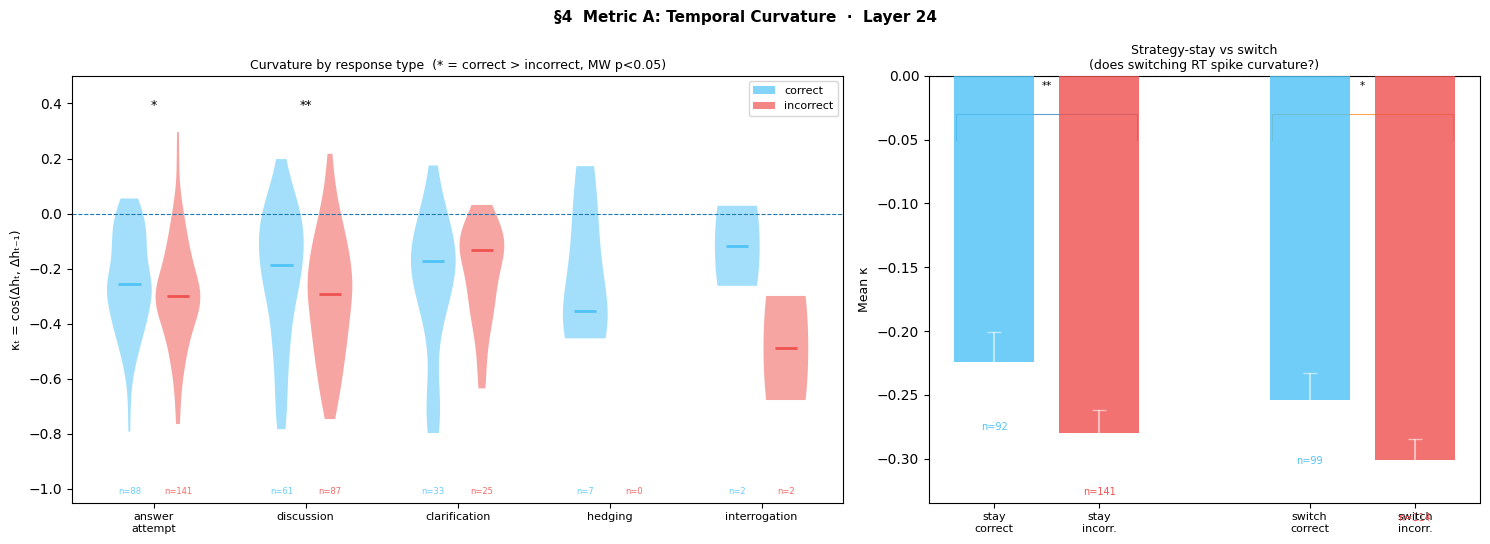

In [9]:
# ── 4.2 Visualise curvature × response type ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5),
                         gridspec_kw={"width_ratios": [1.4, 1]})


# Panel A — curvature violin per RT (correct vs incorrect)
ax = axes[0]; styled_ax(ax)
rt_curve = {rt: {"correct": [], "incorrect": []} for rt in ALL_TYPES}
for r in curv_records:
    if np.isnan(r["curvature"]) or r["rt"] == "missing": continue
    rt_curve[r["rt"]]["correct" if r["score"]==1 else "incorrect"].append(r["curvature"])

present  = [rt for rt in ALL_TYPES if rt_curve[rt]["correct"] or rt_curve[rt]["incorrect"]]
positions = np.arange(len(present))
w = 0.32
for offset, key, clr in [(-w/2, "correct", "#4fc3f7"), (w/2, "incorrect", "#ef5350")]:
    vals_all = [rt_curve[rt][key] for rt in present]
    non_empty = [(i, v) for i, v in enumerate(vals_all) if len(v) > 0]

    # Matplotlib violinplot cannot handle empty arrays; plot only non-empty groups.
    if non_empty:
        idx_non_empty, vals_non_empty = zip(*non_empty)
        pos_non_empty = positions[np.array(idx_non_empty)] + offset
        vp = ax.violinplot(list(vals_non_empty), positions=pos_non_empty,
                           widths=w*0.92, showmedians=True, showextrema=False)
        for body in vp["bodies"]:
            body.set_facecolor(clr); body.set_alpha(0.52)
        vp["cmedians"].set_color(clr); vp["cmedians"].set_linewidth(2)

    for xi, vs in zip(positions+offset, vals_all):
        ax.text(xi, -1.02, f"n={len(vs)}", ha="center", fontsize=6, color=clr, alpha=0.85)

for xi, rt in zip(positions, present):
    vc = rt_curve[rt]["correct"]; vi = rt_curve[rt]["incorrect"]
    star, _ = mw_test(vc, vi, alternative="greater")
    if star not in ("", "n.s.", "—"):
        ax.text(xi, 0.38, star, ha="center", fontsize=9)

ax.set_xticks(positions)
ax.set_xticklabels([rt.replace("_","\n") for rt in present], fontsize=8)
ax.set_ylim(-1.05, 0.5)
ax.set_ylabel("κₜ = cos(Δhₜ, Δhₜ₋₁)", fontsize=9)
ax.set_title("Curvature by response type  (* = correct > incorrect, MW p<0.05)",
             fontsize=9, pad=5)
ax.axhline(0, lw=0.8, ls="--")
ax.legend(handles=[Patch(facecolor="#4fc3f7", alpha=0.7, label="correct"),
                   Patch(facecolor="#ef5350", alpha=0.7, label="incorrect")],
          fontsize=8)

# Panel B — strategy-stay vs strategy-switch
ax = axes[1]; styled_ax(ax)
groups = {("stay",1):[], ("stay",0):[], ("switch",1):[], ("switch",0):[]}
for r in curv_records:
    if np.isnan(r["curvature"]): continue
    key = ("switch" if r["is_switch"] else "stay", r["score"])
    groups[key].append(r["curvature"])

bar_defs = [
    ("stay\ncorrect",  ("stay",  1), "#4fc3f7", 0.00),
    ("stay\nincorr.",  ("stay",  0), "#ef5350", 0.50),
    ("switch\ncorrect",("switch",1), "#4fc3f7", 1.50),
    ("switch\nincorr.",("switch",0), "#ef5350", 2.00),
]
for lbl, key, clr, xpos in bar_defs:
    vals = groups[key]
    if not vals: continue
    mu = np.mean(vals); se = np.std(vals)/np.sqrt(len(vals))
    ax.bar(xpos, mu, 0.38, color=clr, alpha=0.82,
           yerr=se, error_kw=dict(ecolor="#ffffff88", capsize=5), zorder=3)
    ax.text(xpos, mu - se - 0.03, f"n={len(vals)}", ha="center", fontsize=7, color=clr)

for (k1, k2, xs) in [(("stay",1),("stay",0),(0.0,0.5)), (("switch",1),("switch",0),(1.5,2.0))]:
    star, _ = mw_test(groups[k1], groups[k2], alternative="greater")
    if star not in ("", "—"):
        mid = sum(xs)/2
        ax.plot([xs[0]-0.18, xs[0]-0.18, xs[1]+0.18, xs[1]+0.18],
                [-0.05, -0.03, -0.03, -0.05], lw=0.8, alpha=0.7)
        ax.text(mid, -0.01, star, ha="center", fontsize=7.5)

ax.set_xticks([0.0, 0.5, 1.5, 2.0])
ax.set_xticklabels(["stay\ncorrect","stay\nincorr.","switch\ncorrect","switch\nincorr."],
                   fontsize=8)
ax.set_ylabel("Mean κ", fontsize=9)
ax.set_title("Strategy-stay vs switch\n(does switching RT spike curvature?)",
             fontsize=9, pad=5)
ax.axhline(0, lw=0.8, ls="--")

fig.suptitle(f"§4  Metric A: Temporal Curvature  ·  Layer {LAYERS[FOCUS_LAYER_IDX]}",
             fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

## §5  Metric B — Strategy Axis Projection

```
strategy_axis = normalise(μ(h | STRATEGY_POS) − μ(h | STRATEGY_NEG))
coord_t       = (hₜ − μ_global) · strategy_axis
```

`STRATEGY_POS = "answer_attempt"`, `STRATEGY_NEG = "discussion"` (configurable in §1).

| coord > 0 | Closer to commitment pole |
|-----------|--------------------------|
| coord < 0 | Closer to exploration pole |

**Sanity check:** `answer_attempt` turns should rank highest on this axis.  
**Key finding:** Incorrect paths commit to `answer_attempt` earlier — premature lock-in.


In [10]:
# ── 5.1 Build strategy axis + project all turn hidden states ─────────────────
li = FOCUS_LAYER_IDX

v_pos = rt_vectors[li].get(STRATEGY_POS)
v_neg = rt_vectors[li].get(STRATEGY_NEG)
assert v_pos is not None and v_neg is not None, (
    f"RT vectors for '{STRATEGY_POS}' or '{STRATEGY_NEG}' not found. "
    f"Available: {list(rt_vectors[li].keys())}"
)

# Axis and global centre (used by §6 too)
strategy_axis = v_pos - v_neg
strategy_axis = strategy_axis / (np.linalg.norm(strategy_axis) + 1e-9)

print(f"Strategy axis (pre-normalise norm): {np.linalg.norm(v_pos - v_neg):.4f}")
print(f"Poles: '{STRATEGY_POS}' (+) vs '{STRATEGY_NEG}' (−)")

# Project every turn hidden state onto the axis
strat_records = []
for conv_id, rec in conv_records.items():
    score   = score_map.get(conv_id)
    if score is None: continue
    turn_rt = turn_rt_map.get(conv_id, {})

    for tl in rec["turns_hs"]:
        if not tl.startswith("turn_"): continue
        t_idx = turn_index(tl)
        h     = rec["turns_hs"][tl][li]
        coord = float(np.dot(h - global_mean, strategy_axis))
        strat_records.append({
            "conv_id": conv_id,
            "turn"   : t_idx,
            "score"  : score,
            "rt"     : turn_rt.get(t_idx, "missing"),
            "coord"  : coord,
        })

print(f"Strategy projection records: {len(strat_records)}")

# Per-turn mean trajectory
strat_by_turn = defaultdict(lambda: {"correct": [], "incorrect": []})
for r in strat_records:
    strat_by_turn[r["turn"]]["correct" if r["score"]==1 else "incorrect"].append(r["coord"])

strat_turns = sorted(strat_by_turn.keys())
print(f"\nPer-turn strategy coordinate (mean ± SE):")
print(f"{'turn':>5}  {'corr_μ':>8}  n_c  {'incorr_μ':>9}  n_i  {'p(MW)':>9}  diff")
for t in strat_turns:
    vc = strat_by_turn[t]["correct"]
    vi = strat_by_turn[t]["incorrect"]
    if len(vc) < 3 and len(vi) < 3: continue
    star, p = mw_test(vc, vi)
    p_str = f"{p:.3g}" if not np.isnan(p) else "—"
    print(f"{t:>5}  {np.mean(vc):>+8.4f}  {len(vc):>3}  {np.mean(vi):>+9.4f}"
          f"  {len(vi):>3}  {p_str:>9}  {np.mean(vc)-np.mean(vi):+.4f}  {star}")

Strategy axis (pre-normalise norm): 4.2663
Poles: 'answer_attempt' (+) vs 'discussion' (−)
Strategy projection records: 884

Per-turn strategy coordinate (mean ± SE):
 turn    corr_μ  n_c   incorr_μ  n_i      p(MW)  diff
    1   -2.1600  106    -2.9205  113      0.167  +0.7605  n.s.
    2   -0.9285  106    -1.1378  113       0.73  +0.2092  n.s.
    3   +0.9493  106    +1.6359  113       0.12  -0.6867  n.s.
    4   +1.4616   52    +2.3584   73      0.102  -0.8968  n.s.
    5   +2.3261   26    +2.5872   44       0.86  -0.2611  n.s.
    6   +0.0584    7    +3.1921   17    0.00852  -3.1337  **
    7      +nan    0    +3.0739    6          —  +nan  —


/home/jie/anaconda3/envs/attention-tracker/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/jie/anaconda3/envs/attention-tracker/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


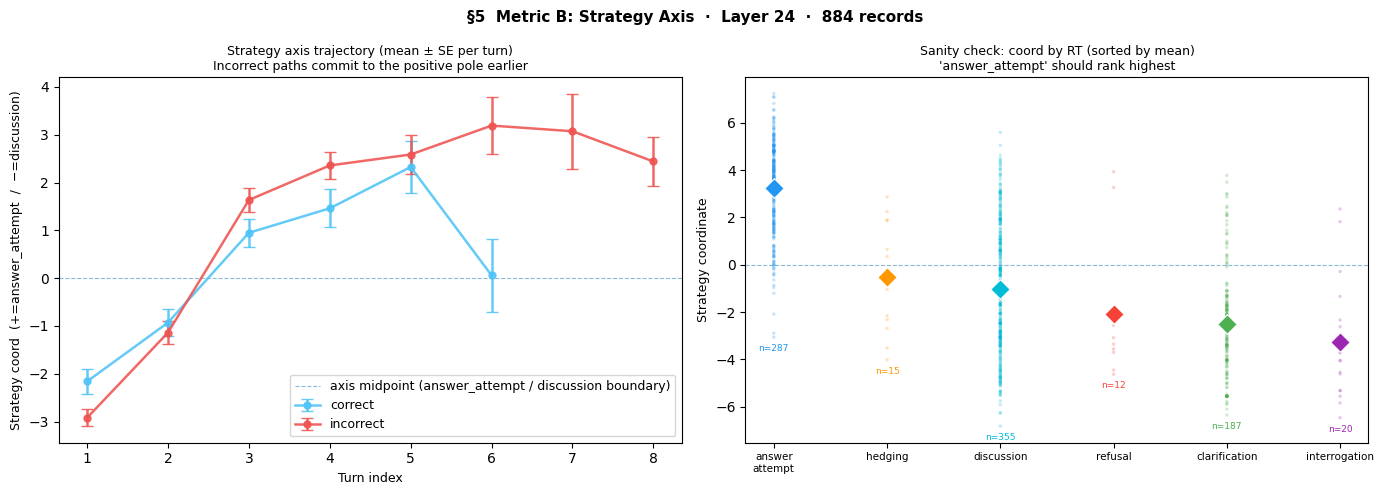

In [11]:
# ── 5.2 Visualise strategy axis ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Panel A — trajectory per turn (mean ± SE)
ax = axes[0]; styled_ax(ax)
for key, clr, lbl in [("correct", "#4fc3f7", "correct"), ("incorrect", "#ef5350", "incorrect")]:
    ts  = [t for t in strat_turns if strat_by_turn[t][key]]
    mus = [np.mean(strat_by_turn[t][key]) for t in ts]
    ses = [np.std(strat_by_turn[t][key]) / np.sqrt(len(strat_by_turn[t][key])) for t in ts]
    ax.errorbar(ts, mus, yerr=ses, marker="o", markersize=5, lw=1.8,
                color=clr, capsize=4, alpha=0.88, label=lbl)
ax.axhline(0, lw=0.8, ls="--", alpha=0.5,
           label=f"axis midpoint ({STRATEGY_POS} / {STRATEGY_NEG} boundary)")
ax.set_xlabel("Turn index", fontsize=9)
ax.set_ylabel(f"Strategy coord  (+={STRATEGY_POS}  /  −={STRATEGY_NEG})",
              fontsize=9)
ax.set_title("Strategy axis trajectory (mean ± SE per turn)\n"
             "Incorrect paths commit to the positive pole earlier",
             fontsize=9, pad=5)
ax.legend(fontsize=9)
ax.set_xticks(strat_turns[:12])

# Panel B — coord by RT (sanity check: answer_attempt should rank highest)
ax = axes[1]; styled_ax(ax)
rt_coords = defaultdict(list)
for r in strat_records:
    if r["rt"] != "missing":
        rt_coords[r["rt"]].append(r["coord"])
rt_order = sorted(rt_coords.keys(), key=lambda rt: np.mean(rt_coords[rt]), reverse=True)
for i, rt in enumerate(rt_order):
    vals = rt_coords[rt]
    ax.scatter([i] * len(vals), vals, s=6, alpha=0.25,
               color=TYPE_COLORS.get(rt, "#aaa"), edgecolors="none")
    ax.scatter(i, np.mean(vals), s=100, color=TYPE_COLORS.get(rt, "#aaa"),
               edgecolors="white", linewidths=0.9, zorder=5, marker="D")
    ax.text(i, np.min(vals) - 0.3, f"n={len(vals)}",
            ha="center", fontsize=6.5, color=TYPE_COLORS.get(rt, "#aaa"), va="top")
ax.set_xticks(range(len(rt_order)))
ax.set_xticklabels([rt.replace("_","\n") for rt in rt_order], fontsize=7.5)
ax.axhline(0, lw=0.8, ls="--", alpha=0.5)
ax.set_ylabel("Strategy coordinate", fontsize=9)
ax.set_title("Sanity check: coord by RT (sorted by mean)\n"
             f"'{STRATEGY_POS}' should rank highest",
             fontsize=9, pad=5)

fig.suptitle(f"§5  Metric B: Strategy Axis  ·  Layer {LAYERS[li]}  ·  {len(strat_records)} records",
             fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

## §6  Metric C — Goal Imprint Gap

`hs["goal"]` is the prefill over `[sys + Shard₀]` — the model's initial encoding of the problem  
before seeing any answers. We project it onto the strategy axis to get a "goal coordinate".

```
goal_coord  = (h_goal − μ_global) · strategy_axis   ← fixed per conversation
gap_t       = coord_t − goal_coord                   ← how far turn t drifted from goal's position
```

**Why gap_t is context-length-free:** both `coord_t` and `goal_coord` are scalar projections  
onto the same axis; their difference cancels the length bias introduced by longer contexts.

| Metric | Captures |
|--------|----------|
| `gap_t1` | Earliest signal of over-commitment |
| `gap_t2` | Point where groups begin separating (empirically turn 2) |
| `gap_max` | Peak over-commitment across all turns |
| `gap_slope` | Whether commitment is accelerating (+) or recovering (−) |

**Hypothesis:** Incorrect paths drift further from the goal's strategy position, faster.


In [12]:
# ── 6.1 Compute goal coordinates and all gap metrics ─────────────────────────
LI = FOCUS_LAYER_IDX

goal_records = []   # one row per conversation

for conv_id, rec in conv_records.items():
    score = score_map.get(conv_id)
    if score is None: continue

    h_goal     = rec["goal_hs"][LI]
    goal_coord = float(np.dot(h_goal - global_mean, strategy_axis))

    turn_labels = sorted(
        [k for k in rec["turns_hs"] if k.startswith("turn_")], key=turn_sort_key
    )
    if not turn_labels: continue

    # Strategy coordinate at each turn
    turn_coords = {
        turn_index(tl): float(np.dot(rec["turns_hs"][tl][LI] - global_mean, strategy_axis))
        for tl in turn_labels
    }

    # gap_t = turn_coord_t − goal_coord  (positive → more committed than goal)
    gaps     = {t: turn_coords[t] - goal_coord for t in turn_coords}
    t_sorted = sorted(gaps.keys())
    g_sorted = [gaps[t] for t in t_sorted]

    # Extended gap metrics
    gap_t1    = gaps.get(t_sorted[0], float("nan"))   # earliest turn available
    gap_t2    = gaps.get(2, float("nan"))
    gap_max   = float(max(g_sorted))
    gap_argmax= t_sorted[int(np.argmax(g_sorted))]

    gap_slope = float("nan")
    if len(g_sorted) >= 3:
        slope, *_ = linregress(t_sorted, g_sorted)
        gap_slope = float(slope)

    goal_records.append({
        "conv_id"   : conv_id,
        "score"     : score,
        "goal_coord": goal_coord,
        "gaps"      : gaps,
        "gap_t1"    : gap_t1,
        "gap_t2"    : gap_t2,
        "gap_max"   : gap_max,
        "gap_slope" : gap_slope,
        "gap_argmax": gap_argmax,
    })

print(f"Goal records: {len(goal_records)}")

# Distribution of goal_coord
all_goal_coords = [r["goal_coord"] for r in goal_records]
print(f"\nGoal strategy coordinate (all convs):")
print(f"  mean={np.mean(all_goal_coords):+.4f}  median={np.median(all_goal_coords):+.4f}"
      f"  std={np.std(all_goal_coords):.4f}")
print(f"  (+1 = {STRATEGY_POS} pole  /  −1 = {STRATEGY_NEG} pole)")

# Stats table
print("\nGap metrics — correct vs incorrect:")
gap_aurocs = print_metric_table(goal_records, ["gap_t1", "gap_t2", "gap_max", "gap_slope"])

# Register in global AUROC registry
for metric, (auc, direc) in gap_aurocs.items():
    clr = {"gap_t1":"#9C27B0","gap_t2":"#AB47BC","gap_max":"#E91E63","gap_slope":"#FF5722"}.get(metric,"#aaa")
    METRIC_AUROCS[f"C: {metric}"] = (auc, direc, clr)

# Combined gap_max + gap_slope (z-scored)
comb_labs = [r["score"]    for r in goal_records if not np.isnan(r["gap_max"]) and not np.isnan(r["gap_slope"])]
comb_arr  = np.column_stack([
    [r["gap_max"]   for r in goal_records if not np.isnan(r["gap_max"]) and not np.isnan(r["gap_slope"])],
    [r["gap_slope"] for r in goal_records if not np.isnan(r["gap_max"]) and not np.isnan(r["gap_slope"])],
])
if len(comb_labs) > 10:
    z_comb  = zscore(comb_arr, axis=0)
    combined_score = z_comb[:, 0] + z_comb[:, 1]
    auroc_gap_combined, _ = best_auroc(comb_labs, combined_score)
    METRIC_AUROCS["C: gap_max+slope"] = (auroc_gap_combined, "+", "#FF9800")
    print(f"  gap_max+slope combined : {auroc_gap_combined:.4f}  Δ={auroc_gap_combined-auroc_curv_base:+.4f}")

Goal records: 219

Goal strategy coordinate (all convs):
  mean=-0.7581  median=-0.8695  std=0.5859
  (+1 = answer_attempt pole  /  −1 = discussion pole)

Gap metrics — correct vs incorrect:
        metric    corr_μ  n_c   incorr_μ  n_i      p(MW)  sig   AUROC
─────────────────────────────────────────────────────────────────────
        gap_t1   -1.4323  106    -2.1339  113    0.09054  n.s.  0.5662 (+)
        gap_t2   -0.2008  106    -0.3512  113     0.7987  n.s.  0.5100 (+)
       gap_max   +3.1014  106    +4.0682  113   0.003768  **    0.6134 (-)
     gap_slope   +1.4754  106    +2.1131  113  0.0005184  ***   0.6358 (-)
  gap_max+slope combined : 0.6442  Δ=-0.0124


/tmp/ipykernel_602413/3658006585.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


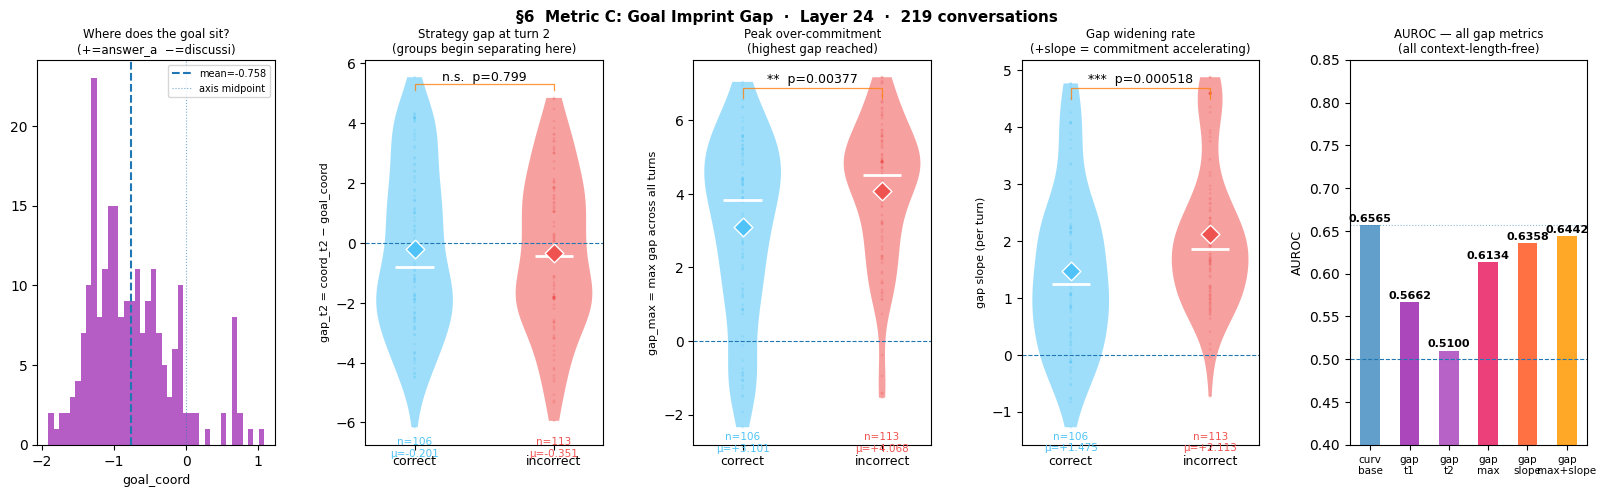

In [13]:
# ── 6.2 Visualise goal imprint gap ───────────────────────────────────────────
fig = plt.figure(figsize=(20, 5))

gs = gridspec.GridSpec(1, 5, figure=fig, wspace=0.38)

def violin_pair(ax, vc, vi, ylabel, title, add_scatter=True):
    """Reusable violin + scatter plot for a correct/incorrect metric comparison."""
    vp = ax.violinplot([vc, vi], positions=[0, 1],
                       widths=0.55, showmedians=True, showextrema=False)
    for body, clr in zip(vp["bodies"], ["#4fc3f7", "#ef5350"]):
        body.set_facecolor(clr); body.set_alpha(0.55)
    vp["cmedians"].set_color("white"); vp["cmedians"].set_linewidth(2)
    for xi, vals, clr in zip([0,1], [vc, vi], ["#4fc3f7", "#ef5350"]):
        if add_scatter:
            ax.scatter([xi]*len(vals), vals, s=4, alpha=0.2, color=clr, edgecolors="none")
        ax.scatter(xi, np.mean(vals), s=90, color=clr, edgecolors="white",
                   linewidths=1.0, zorder=6, marker="D")
        ax.text(xi, min(min(vc), min(vi))*1.05 - 0.01,
                f"n={len(vals)}\nμ={np.mean(vals):+.3f}", ha="center", fontsize=7.5, color=clr, va="top")
    star, p = mw_test(vc, vi)
    if star and star != "—":
        y_top = max(max(vc), max(vi))
        ax.plot([0,0,1,1],[y_top*0.92,y_top*0.96,y_top*0.96,y_top*0.92], lw=0.9, alpha=0.8)
        ax.text(0.5, y_top*0.98, f"{star}  p={p:.3g}", ha="center", fontsize=9)
    ax.axhline(0, lw=0.8, ls="--")
    ax.set_xticks([0,1]); ax.set_xticklabels(["correct","incorrect"], fontsize=9)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(title, fontsize=8.5, pad=5)

# Panel A — goal_coord distribution
ax = fig.add_subplot(gs[0]); styled_ax(ax)
ax.hist(all_goal_coords, bins=40, color="#9C27B0", alpha=0.75)
ax.axvline(np.mean(all_goal_coords), lw=1.5, ls="--",
           label=f"mean={np.mean(all_goal_coords):+.3f}")
ax.axvline(0, lw=0.8, ls=":", alpha=0.6, label="axis midpoint")
ax.set_xlabel("goal_coord", fontsize=9)
ax.set_title(f"Where does the goal sit?\n(+={STRATEGY_POS[:8]}  −={STRATEGY_NEG[:8]})",
             fontsize=8.5, pad=5)
ax.legend(fontsize=7)

# Panel B — gap_t2 violin
ax = fig.add_subplot(gs[1]); styled_ax(ax)
vc_g2 = [r["gap_t2"] for r in goal_records if r["score"]==1 and not np.isnan(r["gap_t2"])]
vi_g2 = [r["gap_t2"] for r in goal_records if r["score"]==0 and not np.isnan(r["gap_t2"])]
violin_pair(ax, vc_g2, vi_g2, "gap_t2 = coord_t2 − goal_coord",
            "Strategy gap at turn 2\n(groups begin separating here)")

# Panel C — gap_max violin
ax = fig.add_subplot(gs[2]); styled_ax(ax)
vc_gm = [r["gap_max"] for r in goal_records if r["score"]==1]
vi_gm = [r["gap_max"] for r in goal_records if r["score"]==0]
violin_pair(ax, vc_gm, vi_gm, "gap_max = max gap across all turns",
            "Peak over-commitment\n(highest gap reached)")

# Panel D — gap_slope violin
ax = fig.add_subplot(gs[3]); styled_ax(ax)
vc_gs = [r["gap_slope"] for r in goal_records if r["score"]==1 and not np.isnan(r["gap_slope"])]
vi_gs = [r["gap_slope"] for r in goal_records if r["score"]==0 and not np.isnan(r["gap_slope"])]
violin_pair(ax, vc_gs, vi_gs, "gap slope (per turn)",
            "Gap widening rate\n(+slope = commitment accelerating)")

# Panel E — AUROC summary
ax = fig.add_subplot(gs[4]); styled_ax(ax)
gap_metric_names = ["gap_t1","gap_t2","gap_max","gap_slope","gap_max+slope"]
gap_auroc_vals = [
    gap_aurocs.get("gap_t1",  (float("nan"),))[0],
    gap_aurocs.get("gap_t2",  (float("nan"),))[0],
    gap_aurocs.get("gap_max", (float("nan"),))[0],
    gap_aurocs.get("gap_slope",(float("nan"),))[0],
    METRIC_AUROCS.get("C: gap_max+slope", (float("nan"),))[0],
]
gap_colors = ["#9C27B0","#AB47BC","#E91E63","#FF5722","#FF9800"]
ax.bar([0]*1, [auroc_curv_base], 0.5, alpha=0.7, label="curvature baseline")
for xi, (nm, auc, clr) in enumerate(zip(gap_metric_names, gap_auroc_vals, gap_colors), start=1):
    if not np.isnan(auc):
        ax.bar(xi, auc, 0.5, color=clr, alpha=0.85)
        ax.text(xi, auc+0.004, f"{auc:.4f}", ha="center", fontsize=8, fontweight="bold")
ax.text(0, auroc_curv_base+0.004, f"{auroc_curv_base:.4f}", ha="center", fontsize=8, fontweight="bold")
ax.axhline(0.5, lw=0.8, ls="--")
ax.axhline(auroc_curv_base, lw=0.8, ls=":", alpha=0.5)
ax.set_xticks(range(len(gap_metric_names)+1))
ax.set_xticklabels(["curv\nbase"]+[nm.replace("_","\n") for nm in gap_metric_names],
                   fontsize=7.5)
ax.set_ylabel("AUROC", fontsize=9)
ax.set_ylim(0.4, 0.85)
ax.set_title("AUROC — all gap metrics\n(all context-length-free)",
             fontsize=8.5, pad=5)

fig.suptitle(f"§6  Metric C: Goal Imprint Gap  ·  Layer {LAYERS[LI]}  ·  {len(goal_records)} conversations",
             fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

## §7  Metric D — Within-Trajectory Variance Collapse

```
trace(Cov(h₁…hₜ))  =  Σ_d  Var_d(h₁:t)          (total hidden-space spread at prefix t)
var_slope          =  linregress slope of trace(Cov) over t
```

| var_slope | Interpretation |
|-----------|----------------|
| > 0 | Hidden states spreading out — exploration |
| < 0 | Collapsing to a narrow region — premature lock-in |

**Hypothesis:** Correct paths explore a wider region of hidden-state space before committing.  
Incorrect paths collapse early — a geometric complement to the strategy axis finding in §5.


In [14]:
# ── 7.1 Compute variance slope per conversation ───────────────────────────────
var_records = []   # one row per conversation

for conv_id, rec in conv_records.items():
    score = score_map.get(conv_id)
    if score is None: continue

    turn_labels = sorted(
        [k for k in rec["turns_hs"] if k.startswith("turn_")], key=turn_sort_key
    )
    if len(turn_labels) < 3: continue

    hs_seq = np.stack([rec["turns_hs"][tl][FOCUS_LAYER_IDX] for tl in turn_labels])  # (T, D)
    T = len(hs_seq)

    # trace(Cov) at each prefix length t (t ≥ 2 to have a covariance)
    trace_covs   = [float(hs_seq[:t].var(axis=0).sum()) for t in range(2, T+1)]
    prefix_turns = list(range(2, T+1))

    if len(trace_covs) < 2: continue

    slope, *_ = linregress(prefix_turns, trace_covs)
    var_records.append({
        "conv_id"    : conv_id,
        "score"      : score,
        "var_slope"  : float(slope),
        "trace_covs" : trace_covs,
        "prefix_turns": prefix_turns,
    })

print(f"Variance records: {len(var_records)}")
print(f"\nVar slope — correct  : mean={np.mean([r['var_slope'] for r in var_records if r['score']==1]):+.2f}")
print(f"Var slope — incorrect: mean={np.mean([r['var_slope'] for r in var_records if r['score']==0]):+.2f}")

# AUROC and register
var_labs = [r["score"]    for r in var_records]
var_vals = [r["var_slope"] for r in var_records]
auroc_var, var_direction = best_auroc(var_labs, var_vals)
METRIC_AUROCS["D: var_slope"] = (auroc_var, var_direction, "#4fc3f7")

star_var, p_var = mw_test(
    [r["var_slope"] for r in var_records if r["score"]==1],
    [r["var_slope"] for r in var_records if r["score"]==0]
)
print(f"MW test: {star_var}  p={p_var:.4g}")
print(f"AUROC ({var_direction}var_slope → correct): {auroc_var:.4f}  Δ={auroc_var-auroc_curv_base:+.4f}")

Variance records: 219

Var slope — correct  : mean=+16.92
Var slope — incorrect: mean=+14.40
MW test: **  p=0.003471
AUROC (+var_slope → correct): 0.6144  Δ=-0.0422


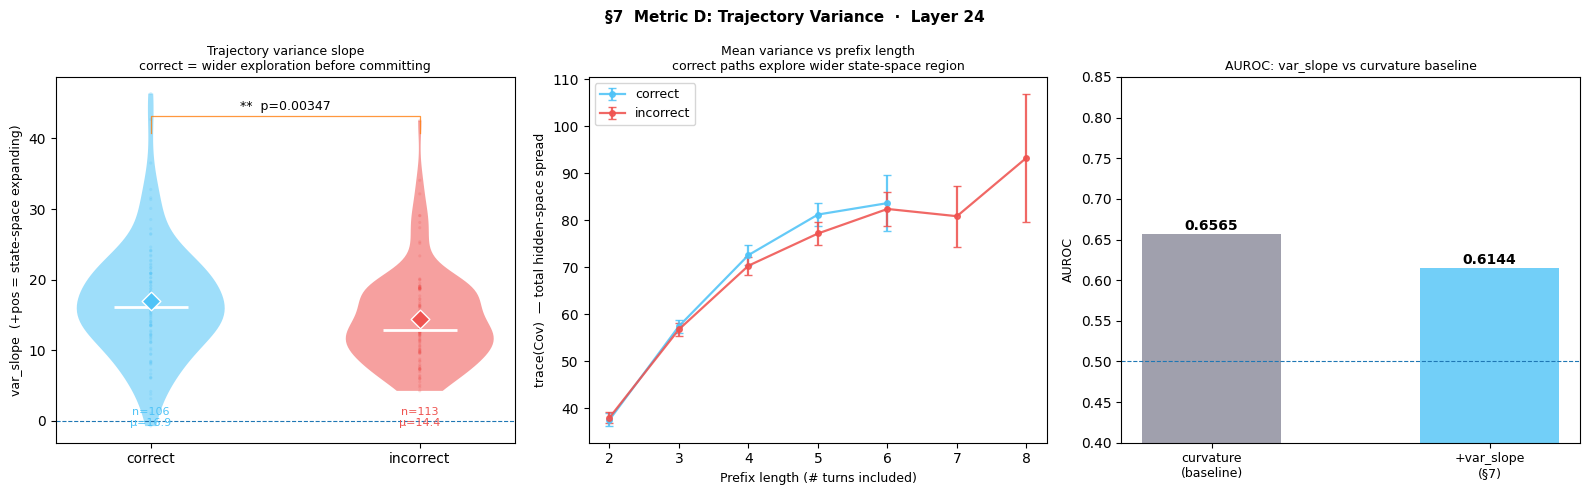

In [15]:
# ── 7.2 Visualise trajectory variance ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))


slopes_c = [r["var_slope"] for r in var_records if r["score"]==1]
slopes_i = [r["var_slope"] for r in var_records if r["score"]==0]

# Panel A — var_slope violin
ax = axes[0]; styled_ax(ax)
vp = ax.violinplot([slopes_c, slopes_i], positions=[0,1],
                   widths=0.55, showmedians=True, showextrema=False)
for body, clr in zip(vp["bodies"], ["#4fc3f7","#ef5350"]):
    body.set_facecolor(clr); body.set_alpha(0.55)
vp["cmedians"].set_color("white"); vp["cmedians"].set_linewidth(2)
for xi, vals, clr in zip([0,1],[slopes_c,slopes_i],["#4fc3f7","#ef5350"]):
    ax.scatter([xi]*len(vals), vals, s=5, alpha=0.2, color=clr, edgecolors="none")
    ax.scatter(xi, np.mean(vals), s=90, color=clr, edgecolors="white",
               linewidths=1.0, zorder=6, marker="D")
    ax.text(xi, min(slopes_c+slopes_i)*1.02,
            f"n={len(vals)}\nμ={np.mean(vals):.1f}", ha="center", fontsize=8, color=clr)
y_top = max(max(slopes_c), max(slopes_i))
ax.plot([0,0,1,1],[y_top*0.88,y_top*0.93,y_top*0.93,y_top*0.88], lw=0.9, alpha=0.8)
ax.text(0.5, y_top*0.95, f"{star_var}  p={p_var:.3g}", ha="center", fontsize=9)
ax.axhline(0, lw=0.8, ls="--")
ax.set_xticks([0,1]); ax.set_xticklabels(["correct","incorrect"], fontsize=10)
ax.set_ylabel("var_slope  (+pos = state-space expanding)", fontsize=9)
ax.set_title("Trajectory variance slope\ncorrect = wider exploration before committing",
             fontsize=9, pad=5)

# Panel B — mean trace(Cov) trajectory per prefix length
ax = axes[1]; styled_ax(ax)
traj = defaultdict(lambda: {"correct":[], "incorrect":[]})
for vr in var_records:
    key = "correct" if vr["score"]==1 else "incorrect"
    for t, v in zip(vr["prefix_turns"], vr["trace_covs"]):
        traj[t][key].append(v)
t_keys = sorted(traj.keys())
for key, clr, lbl in [("correct","#4fc3f7","correct"),("incorrect","#ef5350","incorrect")]:
    ts  = [t for t in t_keys if traj[t][key]]
    mus = [np.mean(traj[t][key]) for t in ts]
    ses = [np.std(traj[t][key])/np.sqrt(len(traj[t][key])) for t in ts]
    ax.errorbar(ts, mus, yerr=ses, marker="o", markersize=4, lw=1.6,
                color=clr, capsize=3, alpha=0.88, label=lbl)
ax.set_xlabel("Prefix length (# turns included)", fontsize=9)
ax.set_ylabel("trace(Cov)  — total hidden-space spread", fontsize=9)
ax.set_title("Mean variance vs prefix length\ncorrect paths explore wider state-space region",
             fontsize=9, pad=5)
ax.legend(fontsize=9)

# Panel C — AUROC comparison
ax = axes[2]; styled_ax(ax)
auroc_names = ["curvature\n(baseline)", f"{var_direction}var_slope\n(§7)"]
auroc_vals  = [auroc_curv_base, auroc_var]
auroc_clrs  = ["#888899", "#4fc3f7"]
for xi, (nm, auc, clr) in enumerate(zip(auroc_names, auroc_vals, auroc_clrs)):
    ax.bar(xi, auc, 0.5, color=clr, alpha=0.8)
    ax.text(xi, auc+0.005, f"{auc:.4f}", ha="center", fontsize=10, fontweight="bold")
ax.axhline(0.5, lw=0.8, ls="--")
ax.set_xticks([0,1]); ax.set_xticklabels(auroc_names, fontsize=9)
ax.set_ylabel("AUROC", fontsize=9)
ax.set_ylim(0.4, 0.85)
ax.set_title("AUROC: var_slope vs curvature baseline",
             fontsize=9, pad=5)

fig.suptitle(f"§7  Metric D: Trajectory Variance  ·  Layer {LAYERS[FOCUS_LAYER_IDX]}",
             fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

## §8  Metric E — Strategy Reversals

```
reversal at turn t = sign(coord_t − coord_{t-1}) ≠ sign(coord_{t-1} − coord_{t-2})
rev_rate           = n_reversals / (n_turns − 2)
```

A reversal is a direction change on the strategy axis — the model oscillates between  
exploration and commitment before settling on one mode.

**Hypothesis:** Correct paths oscillate more before committing.  
They explore the strategy axis rather than prematurely locking in.

**Check:** Panel B verifies `rev_rate` is not merely a proxy for conversation length.

**Combined (§9):** `z(var_slope) + z(rev_rate)` tests whether both §7 and §8 signals are additive.


In [16]:
# ── 8.1 Compute reversal rate per conversation ────────────────────────────────
# Requires strat_records (§5) to provide per-turn strategy coordinates.

conv_strat = defaultdict(list)
for r in strat_records:
    conv_strat[r["conv_id"]].append((r["turn"], r["coord"]))
for cid in conv_strat:
    conv_strat[cid].sort(key=lambda x: x[0])

rev_records = []
for conv_id, seq in conv_strat.items():
    score = score_map.get(conv_id)
    if score is None or len(seq) < 3: continue

    coords = np.array([c for _, c in seq])
    diffs  = np.diff(coords)

    n_rev = int(sum(
        np.sign(diffs[i]) != np.sign(diffs[i-1]) and diffs[i] != 0 and diffs[i-1] != 0
        for i in range(1, len(diffs))
    ))
    rev_rate = n_rev / max(len(coords) - 2, 1)

    rev_records.append({
        "conv_id"  : conv_id,
        "score"    : score,
        "rev_rate" : rev_rate,
        "n_rev"    : n_rev,
        "n_turns"  : len(coords),
    })

print(f"Reversal records: {len(rev_records)}")
rev_c = [r["rev_rate"] for r in rev_records if r["score"]==1]
rev_i = [r["rev_rate"] for r in rev_records if r["score"]==0]
print(f"\nReversal rate  correct  : mean={np.mean(rev_c):.4f}  n={len(rev_c)}")
print(f"Reversal rate  incorrect: mean={np.mean(rev_i):.4f}  n={len(rev_i)}")

star_rev, p_rev = mw_test(rev_c, rev_i)
print(f"MW test: {star_rev}  p={p_rev:.4g}")

rev_labs = [r["score"]   for r in rev_records]
rev_vals = [r["rev_rate"] for r in rev_records]
auroc_rev, rev_direction = best_auroc(rev_labs, rev_vals)
METRIC_AUROCS["E: rev_rate"] = (auroc_rev, rev_direction, "#4CAF50")
print(f"AUROC ({rev_direction}rev_rate → correct): {auroc_rev:.4f}  Δ={auroc_rev-auroc_curv_base:+.4f}")

# Combined: z(var_slope) + z(rev_rate)
var_map = {r["conv_id"]: r["var_slope"] for r in var_records}
comb_labs, comb_vs, comb_rr = [], [], []
for rr in rev_records:
    cid = rr["conv_id"]
    if cid in var_map:
        comb_labs.append(rr["score"])
        comb_vs.append(var_map[cid])
        comb_rr.append(rr["rev_rate"])

if comb_labs:
    arr = np.column_stack([comb_vs, comb_rr])
    z   = zscore(arr, axis=0)
    combined = z[:,0] + z[:,1]   # both signals: higher = more likely correct
    auroc_combined, _ = best_auroc(comb_labs, combined)
    METRIC_AUROCS["E: var+rev"] = (auroc_combined, "+", "#FF9800")
    print(f"AUROC (var_slope + rev_rate combined, n={len(comb_labs)}): {auroc_combined:.4f}"
          f"  Δ={auroc_combined-auroc_curv_base:+.4f}")

Reversal records: 219

Reversal rate  correct  : mean=0.4261  n=106
Reversal rate  incorrect: mean=0.3310  n=113
MW test: n.s.  p=0.115
AUROC (+rev_rate → correct): 0.5583  Δ=-0.0983
AUROC (var_slope + rev_rate combined, n=219): 0.5999  Δ=-0.0566


/tmp/ipykernel_602413/3854684734.py:31: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter([r["n_turns"] for r in pts], [r["rev_rate"] for r in pts],


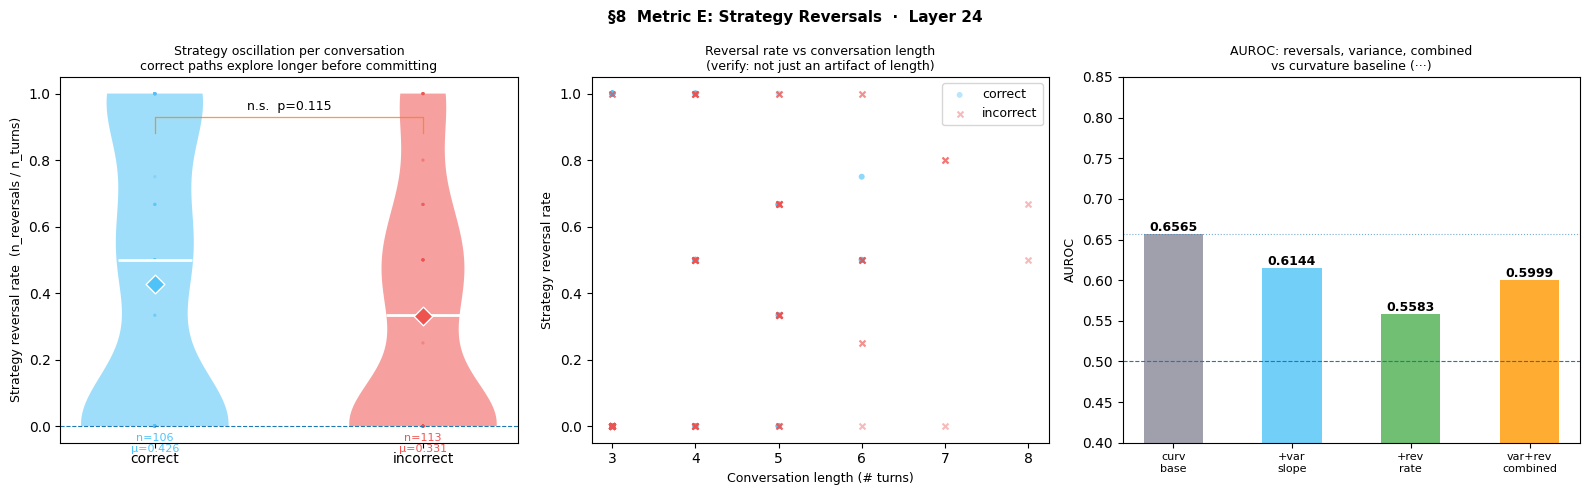

In [17]:
# ── 8.2 Visualise strategy reversals ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))


# Panel A — rev_rate violin
ax = axes[0]; styled_ax(ax)
vp = ax.violinplot([rev_c, rev_i], positions=[0,1],
                   widths=0.55, showmedians=True, showextrema=False)
for body, clr in zip(vp["bodies"], ["#4fc3f7","#ef5350"]):
    body.set_facecolor(clr); body.set_alpha(0.55)
vp["cmedians"].set_color("white"); vp["cmedians"].set_linewidth(2)
for xi, vals, clr in zip([0,1],[rev_c,rev_i],["#4fc3f7","#ef5350"]):
    ax.scatter([xi]*len(vals), vals, s=5, alpha=0.2, color=clr, edgecolors="none")
    ax.scatter(xi, np.mean(vals), s=90, color=clr, edgecolors="white",
               linewidths=1.0, zorder=6, marker="D")
    ax.text(xi, -0.02, f"n={len(vals)}\nμ={np.mean(vals):.3f}",
            ha="center", fontsize=8, color=clr, va="top")
y_top = max(max(rev_c), max(rev_i))
ax.plot([0,0,1,1],[y_top*0.88,y_top*0.93,y_top*0.93,y_top*0.88], lw=0.9, alpha=0.8)
ax.text(0.5, y_top*0.95, f"{star_rev}  p={p_rev:.3g}", ha="center", fontsize=9)
ax.axhline(0, lw=0.8, ls="--")
ax.set_xticks([0,1]); ax.set_xticklabels(["correct","incorrect"], fontsize=10)
ax.set_ylabel("Strategy reversal rate  (n_reversals / n_turns)", fontsize=9)
ax.set_title("Strategy oscillation per conversation\ncorrect paths explore longer before committing",
             fontsize=9, pad=5)

# Panel B — rev_rate vs n_turns scatter (length-independence check)
ax = axes[1]; styled_ax(ax)
for score_val, clr, lbl, mk in [(1,"#4fc3f7","correct","o"),(0,"#ef5350","incorrect","x")]:
    pts = [r for r in rev_records if r["score"]==score_val]
    ax.scatter([r["n_turns"] for r in pts], [r["rev_rate"] for r in pts],
               s=18, alpha=0.4, color=clr, edgecolors="none", marker=mk, label=lbl)
ax.set_xlabel("Conversation length (# turns)", fontsize=9)
ax.set_ylabel("Strategy reversal rate", fontsize=9)
ax.set_title("Reversal rate vs conversation length\n"
             "(verify: not just an artifact of length)",
             fontsize=9, pad=5)
ax.legend(fontsize=9)

# Panel C — AUROC comparison
ax = axes[2]; styled_ax(ax)
auroc_panel = [
    ("curv\nbase",  auroc_curv_base, "#888899"),
    (f"{var_direction}var\nslope", auroc_var, "#4fc3f7"),
    (f"{rev_direction}rev\nrate",  auroc_rev, "#4CAF50"),
    ("var+rev\ncombined", METRIC_AUROCS.get("E: var+rev",(float("nan"),))[0], "#FF9800"),
]
for xi, (lbl, auc, clr) in enumerate(auroc_panel):
    if not np.isnan(auc):
        ax.bar(xi, auc, 0.5, color=clr, alpha=0.8)
        ax.text(xi, auc+0.004, f"{auc:.4f}", ha="center", fontsize=9,
                fontweight="bold")
ax.axhline(0.5, lw=0.8, ls="--")
ax.axhline(auroc_curv_base, lw=0.8, ls=":", alpha=0.6)
ax.set_xticks(range(len(auroc_panel)))
ax.set_xticklabels([l for l,_,_ in auroc_panel], fontsize=8)
ax.set_ylabel("AUROC", fontsize=9)
ax.set_ylim(0.4, 0.85)
ax.set_title("AUROC: reversals, variance, combined\nvs curvature baseline (···)",
             fontsize=9, pad=5)

fig.suptitle(f"§8  Metric E: Strategy Reversals  ·  Layer {LAYERS[FOCUS_LAYER_IDX]}",
             fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

## §9  Summary — AUROC Comparison

All metrics predict binary conversation outcome (correct=1). AUROC = 0.5 is chance.

Each metric is registered in `METRIC_AUROCS` as it is computed, so this cell is  
automatically populated when run after §4–§8.

| Section | Metric | Signal direction |
|---------|--------|-----------------|
| §4 | `mean_curvature` | higher = more correct |
| §6 | `gap_t1/t2/max/slope` | lower gap = more correct |
| §7 | `var_slope` | higher = more correct |
| §8 | `rev_rate`, `var+rev` | higher = more correct |


Metric                         AUROC  dir   Δ vs baseline
────────────────────────────────────────────────────────────
A: mean_curvature             0.6565    +         +0.0000  ◀
C: gap_t1                     0.5662    +         -0.0903  
C: gap_t2                     0.5100    +         -0.1465  
C: gap_max                    0.6134    -         -0.0432  
C: gap_slope                  0.6358    -         -0.0207  
C: gap_max+slope              0.6442    +         -0.0124  
D: var_slope                  0.6144    +         -0.0422  
E: rev_rate                   0.5583    +         -0.0983  
E: var+rev                    0.5999    +         -0.0566  


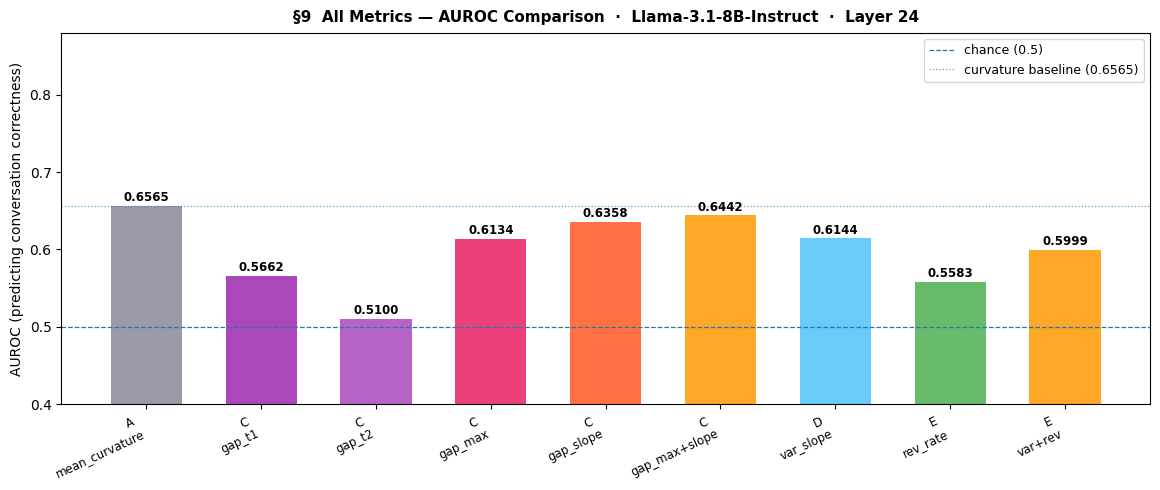

In [18]:
# ── §9 AUROC Summary ──────────────────────────────────────────────────────────
# METRIC_AUROCS is populated by §4–§8.
# Format: metric_name → (auroc, direction, hex_color)

if not METRIC_AUROCS:
    print("No metrics registered. Run §4–§8 first.")
else:
    print(f"{'Metric':<28}  {'AUROC':>6}  {'dir':>3}  {'Δ vs baseline':>14}")
    print("─" * 60)

    baseline_auc = METRIC_AUROCS.get("A: mean_curvature", (0.5,))[0]
    for name, (auc, direc, _) in METRIC_AUROCS.items():
        delta = f"{auc - baseline_auc:+.4f}" if "baseline" not in name.lower() else "—"
        marker = "◀" if auc == max(v[0] for v in METRIC_AUROCS.values()) else ""
        print(f"{name:<28}  {auc:>6.4f}  {direc:>3}  {delta:>14}  {marker}")

    # ── Figure ────────────────────────────────────────────────────────────────
    names  = list(METRIC_AUROCS.keys())
    aucs   = [METRIC_AUROCS[n][0] for n in names]
    colors = [METRIC_AUROCS[n][2] for n in names]

    fig, ax = plt.subplots(figsize=(max(9, len(names)*1.3), 5))
    styled_ax(ax)

    ax.bar(range(len(names)), aucs, 0.62, color=colors, alpha=0.85)
    ax.axhline(0.5, lw=0.9, ls="--", label="chance (0.5)")
    ax.axhline(baseline_auc, lw=0.9, ls=":", alpha=0.7,
               label=f"curvature baseline ({baseline_auc:.4f})")

    for xi, auc in enumerate(aucs):
        ax.text(xi, auc + 0.006, f"{auc:.4f}", ha="center", fontsize=8.5,
                fontweight="bold")

    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.replace(": "," \n") for n in names],
                       rotation=25, ha="right", fontsize=8.5)
    ax.set_ylabel("AUROC (predicting conversation correctness)", fontsize=10)
    ax.set_ylim(0.40, 0.88)
    ax.legend(fontsize=9)
    ax.set_title(
        f"§9  All Metrics — AUROC Comparison  ·  Llama-3.1-8B-Instruct  ·  Layer {LAYERS[FOCUS_LAYER_IDX]}",
        fontsize=11, fontweight="bold", pad=8
    )
    plt.tight_layout()
    plt.show()
